In [3]:
#데이터셋 불러오기
from sklearn.datasets import fetch_openml
X,y=fetch_openml('titanic', version=1, as_frame=True, return_X_y=True, parser='auto')

In [4]:
#사용할 데이터 선택
import pandas as pd

df=pd.concat([X,y],axis=1)
df=df[['pclass','sex','age','sibsp','parch','fare','embarked','survived']]

In [5]:
#데이터 전처리
df['survived']=df['survived'].astype(int)
df['pclass']=df['pclass'].astype(int)
df=df.dropna().reset_index(drop=True)

In [16]:
#조건부확률
#미성년자(18세 미만)가 생존할 확률

p_minor=(df['age']<18).sum()/len(df)
p_survive_and_minor=((df['age']<=18)&(df['survived']==1)).sum()/len(df)
p_survive_given_minor=p_survive_and_minor/p_minor

print(f'P(미성년자)={p_minor:.4f}')
print(f'P(생존∩미성년자)={p_survive_and_minor:.4f}')
print(f'P(생존|미성년자)={p_survive_and_minor:.4f}/{p_minor:.4f}={p_survive_given_minor*100:.2f}')

P(미성년자)=0.1477
P(생존∩미성년자)=0.0911
P(생존|미성년자)=0.0911/0.1477=61.69


In [17]:
#독립
#혼자 탑승하는 것과 생존은 독립인지
event_a=((df['sibsp']==0)&(df['parch']==0))
event_b=(df['survived']==1)

p_a=event_a.sum()/len(df)
p_b=event_b.sum()/len(df)
p_a_and_b=(event_a&event_b).sum()/len(df)
if p_a_and_b==(p_a*p_b):
    print('두 사건은 독립 (Independent)')
else:
    print('두 사건은 종속 (Dependent)')

두 사건은 종속 (Dependent)


In [21]:
#전확률
#요금을 분할로 전체 생존율 계산
low=df[df['fare']<50]
mid=df[(df['fare']>=50)&(df['fare']<100)]
high=df[df['fare']>=100]

p_b1=len(low)/len(df)
p_b2=len(mid)/len(df)
p_b3=len(high)/len(df)

p_survive_b1=1-(low['survived'].sum()/len(low))
p_survive_b2=1-(mid['survived'].sum()/len(mid))
p_survive_b3=1-(high['survived'].sum()/len(high))

p_survive=p_survive_b1*p_b1+p_survive_b2*p_b2+p_survive_b3*p_b3

print(f'P(생존|저가(0~50)) x P(저가(0~50))={p_survive_b1:.4f}x{p_b1:.4f}={p_survive_b1*p_b1:.4f}')
print(f'P(생존|중간가(50~100)) x P(중간가(50~100))={p_survive_b2:.4f}x{p_b2:.4f}={p_survive_b2*p_b2:.4f}')
print(f'P(생존|고가(100~)) x P(고가(100~))={p_survive_b3:.4f}x{p_b3:.4f}={p_survive_b3*p_b3:.4f}')
print(f'P(생존)={p_survive:.4f} / 직접 계산:{1-df["survived"].sum()/len(df):.4f}')

P(생존|저가(0~50)) x P(저가(0~50))=0.6619x0.7967=0.5273
P(생존|중간가(50~100)) x P(중간가(50~100))=0.3459x0.1275=0.0441
P(생존|고가(100~)) x P(고가(100~))=0.2785x0.0757=0.0211
P(생존)=0.5925 / 직접 계산:0.5925


In [14]:
#베이즈 정리
#승선한 항구 정보를 알 때, 그 사람이 생존할 사후 확률

groups=sorted(df['embarked'].unique())
p_evidence=(df['survived']==1).sum()/len(df)

for g in groups:
    grp=df[df['embarked']==g]
    p_bi=len(grp)/len(df)
    p_a_bi=(grp['survived']==1).sum()/len(grp)
    p_bi_a=(p_a_bi*p_bi)/p_evidence
    print(f'pclass가 {g}일 때')
    print(f'-사전확률 P(b_i)={p_bi:.4f}')
    print(f'-사후확률 P(b_i|a)={p_bi_a:.4f}')

pclass가 C일 때
-사전확률 P(b_i)=0.2033
-사후확률 P(b_i|a)=0.3106
pclass가 Q일 때
-사전확률 P(b_i)=0.0479
-사후확률 P(b_i|a)=0.0306
pclass가 S일 때
-사전확률 P(b_i)=0.7488
-사후확률 P(b_i|a)=0.6588


([<matplotlib.patches.Wedge at 0x27d9522ecd0>,
 [Text(0.7809762804906959, 0.7746457573051815, 'survived'),
  Text(-0.7809762589414951, -0.7746457790304849, 'death')])

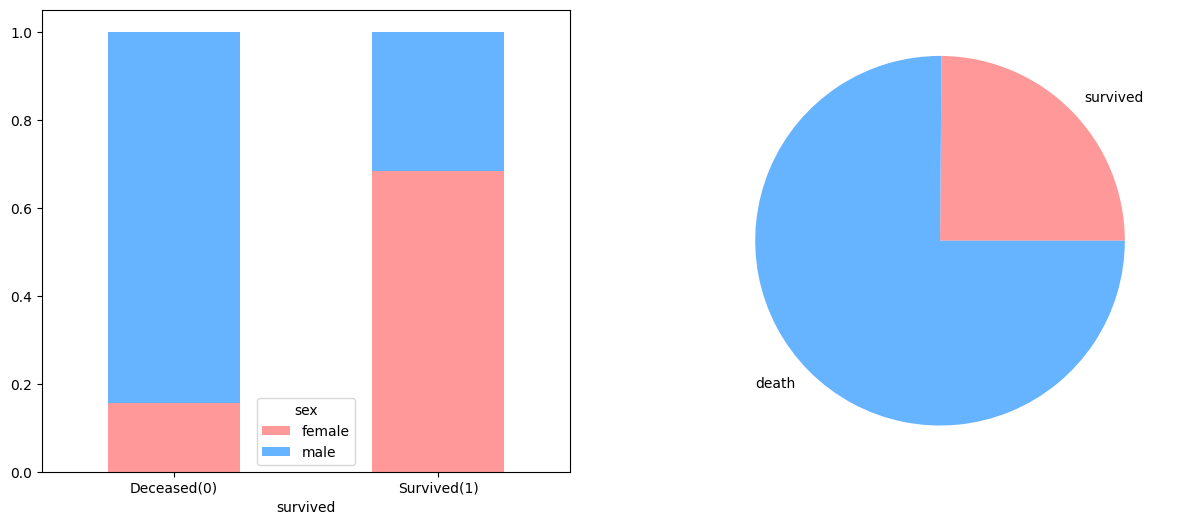

In [ ]:
import matplotlib.pyplot as plt

#axes=왼쪽/오른쪽 공간 구분, figsize=그래프 크기 조절
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#ff9999', '#66b3ff']

p_female=(df['sex']=='female').sum()/len(df)
p_survive_and_female=((df['sex']=='female')&(df['survived']==1)).sum()/len(df)
p_survive_given_female=p_survive_and_female/p_female

#왼쪽 막대 그래프
crosstab = pd.crosstab(df['survived'], df['sex'], normalize='index') #crosstab->교차표 생성(survive:행, sex:열) / normalize-> 가로 줄의 합계를 1로(명수가 아닌 비율로)
crosstab.plot(kind='bar', stacked=True, color=colors, ax=axes[0]) #stacekd=True->막대 그래프를 위로 쌓겠다
axes[0].set_xticklabels(['Deceased(0)', 'Survived(1)'], rotation=0) #set_xticklabels->가로축 이름 지정, rotation->글자를 가로로 출력

#오른쪽 원형 그래프
pie_data=[1-p_survive_given_female, p_survive_given_female]
axes[1].pie(pie_data, labels=['survived','death'],colors=colors)